# Deep Learning with Python - 3th ed.
Francois Chollet
Matthew Watson


<img src="../pics/cover_DeepLearning.jpg" width=400> 

https://github.com/fchollet/deep-learning-with-python-notebooks

https://github.com/cr2003/BK_DeepLearning_with_Python_3ed



<a href="file:///C:/Users/crodr/OneDrive/InterChange/Books/Tech/DeepLearnig/Deep Learning with Python, Third Edition (François Chollet, Matthew Watson) (z-library.sk, 1lib.sk, z-lib.sk).pdf" target="_blank">Abrir PDF Local</a>

In [3]:
import os

# Definimos la ruta de tu libro
ruta_libro = r"C:\Users\crodr\OneDrive\InterChange\Books\Tech\DeepLearnig\Deep Learning with Python, Third Edition (François Chollet, Matthew Watson) (z-library.sk, 1lib.sk, z-lib.sk).pdf"

# Esto le dice a Windows: "Abre este archivo con el programa por defecto del sistema"
os.startfile(ruta_libro)

In [1]:
!pwd

/c/Users/crodr/BK_tech/DeepLearning/BK_DeepLearning_with_Python_3ed/ch03


In [2]:
!python --version

Python 3.12.10


In [3]:
# check jax installation
import jax

print(jax.devices())

[CpuDevice(id=0)]


# Chapter 03 - Introduction to TensorFlow, PyTorch, JAX, and Keras
## 3.5 Introduction to JAX

### 3.5.2 Tensors in JAX
page 83

One of the best features of JAX is that it doesn’t try to implement its own independent,
similar-to-NumPy-but-slightly-divergent numerical API. Instead, it just implements the
NumPy API, as is. It is available as the `jax.numpy` namespace, and you will often see it
imported as `jnp` for short.

Here are some JAX arrays.

In [4]:
from jax import numpy as jnp

jnp.ones(shape=(2, 1))

Array([[1.],
       [1.]], dtype=float32)

In [8]:
jnp.zeros(shape=(2, 1))

Array([[0.],
       [0.]], dtype=float32)

In [9]:
jnp.array([1, 2, 3], dtype="float32")

Array([1., 2., 3.], dtype=float32)

### Random number generation in JAX

The first difference between JAX and NumPy has to do with the way JAX handles random
operations—what is known as “PRNG” (Pseudo-Random Number Generation)
operations. We said earlier that JAX is stateless, which implies that JAX code can’t rely
on any hidden global state. Consider the following NumPy code.

In [ ]:
import numpy as np

np.random.normal(size=(3,))

array([0.7903634 , 0.67611351, 0.60394185])

In [ ]:
np.random.normal(size=(3,))

array([-0.35630993, -0.50804664,  0.42324089])

How did the second call to `np.random.normal()` know to return a different value from
the first call? That’s right—it’s a hidden piece of global state. You can actually retrieve
that global state via `np.random.get_state()` and set it via `np.random.seed(seed)`.
In a stateless framework, we can’t have any such global state. The same API call must
always return the same value. As a result, in a stateless version of NumPy, you would have
to rely on passing different seed arguments to your `np.random` calls to get different values.

Now, it’s often the case that your PRNG calls are going to be in functions that get
called multiple times and that are intended to use different random values each time.
If you don’t want to rely on any global state, this requires you to manage your seed state
outside of the target function, like this:

In [ ]:
x = np.random.normal(size=(3,))


def apply_noise(x, seed):
    np.random.seed(seed)
    x = x * np.random.normal((3,))
    return x


seed = 1337
y = apply_noise(x, seed)
seed += 1
z = apply_noise(x, seed)
print(f"x: {x}")
print(f"y: {y}")
print(f"z: {z}")


x: [ 0.06905289 -1.36994721 -1.73542443]
y: [ 0.15860155 -3.14651214 -3.98594485]
z: [ 0.22810901 -4.52547775 -5.73279363]


It’s basically the same in JAX. However, JAX doesn’t use integer seeds. It uses special
array structures called keys. You can create one from an integer value, like this:

In [16]:
import jax

seed_key = jax.random.key(1337)
seed_key

Array((), dtype=key<fry>) overlaying:
[   0 1337]

To force you to always provide a seed “key” to PRNG calls, all JAX PRNG-using operations
take `key` (the random seed) as their first positional argument. Here’s how to use
`random.normal()`:

In [ ]:
seed_key = jax.random.key(0)
jax.random.normal(seed_key, shape=(3,))


Array([ 1.6226422 ,  2.0252647 , -0.43359444], dtype=float32)

Two calls to `random.normal()` that receive the same seed key will always return the same
value.

In [ ]:
seed_key = jax.random.key(123)
jax.random.normal(seed_key, shape=(3,))

Array([1.6359469 , 0.8408094 , 0.02212393], dtype=float32)

In [ ]:
jax.random.normal(seed_key, shape=(3,))


Array([1.6359469 , 0.8408094 , 0.02212393], dtype=float32)

If you need a new seed key, you can simply create a new one from an existing one using
the `jax.random.split()` function. It is deterministic, so the same sequence of splits will
always result in the same final seed key:

In [ ]:
seed_key = jax.random.key(123)
jax.random.normal(seed_key, shape=(3,))

Array([1.6359469 , 0.8408094 , 0.02212393], dtype=float32)

In [ ]:
new_seed_key = jax.random.split(seed_key, num=1)[
    0
]  # You could even split your key into multiple new keys at once!
jax.random.normal(new_seed_key, shape=(3,))

Array([-0.49093357, -0.9478693 , -1.775197  ], dtype=float32)

This is definitely more work than `np.random`! But the benefits of statelessness far outweigh
the costs: it makes your code vectorizable (i.e., the JAX compiler can automatically
turn it into highly parallel code) while maintaining determinism (i.e., you can run
the same code twice with the same results). That is impossible to achieve with a global
PRNG state.

#### Tensor Assignment
page 85

The second difference between JAX and NumPy is tensor assignment. Like in Tensor-
Flow, JAX arrays are not assignable in place. That’s because any sort of in-place modification
would go against JAX’s stateless design. Instead, if you need to update a tensor,
you must create a new tensor with the desired value. JAX makes this easy by providing
the `at()/set()` API. These methods allow you to create a new tensor with an updated
element at a specific index. Here’s an example of how you would update the first element
of a JAX array to a new value.

In [6]:
x = jnp.array([1, 2, 3], dtype="float32")
new_x = x.at[0].set(10)
new_x

Array([10.,  2.,  3.], dtype=float32)

#### Tensor Operations: Doing math in JAX

Doing math in JAX looks exactly the same as it does in NumPy. No need to learn anything
new this time!


In [ ]:
a = jnp.ones((2, 2))
b = jnp.square(a)  # takes the square
c = jnp.sqrt(a)  # takes the square root
d = b + c  # adds two tensors (element-wise)
e = jnp.matmul(a, b)  # takes the product of two tensors
e *= d  # multiplies two tensors (element-wise)


Here's a dense layer:

In [8]:
def dense(inputs, W, b):
    return jax.nn.relu(jnp.matmul(inputs, W) + b)

#### Computing Gradients with JAX
Unlike TensorFlow and PyTorch, JAX takes a metaprogramming approach to gradient
computation. Metaprogramming refers to the idea of having functions that return functions—
you could call them “meta-functions.” In practice, JAX lets you `turn a loss-computation function` 
into a `gradient-computation function`. So computing gradients in JAX is a
three-step process:

1. Define a loss function, `compute_loss()`.

2.  Call `grad_fn = jax.grad(compute_loss)` to retrieve a gradient-computation function.

3. Call `grad_fn` to retrieve the gradient values.

The loss function should verify the following properties:

* It should return a scalar loss value.

* Its first argument (which, in the following example, is also the only argument)
should contain the state arrays we need gradients for. This argument is usually
named state. For instance, this first argument could be a single array, a list of
arrays, or a dict of arrays.

Let’s take a look at a simple example. Here’s a loss-computation function that takes
a single scalar, input_var and returns a scalar loss value—just the square of the
input:


In [9]:
def compute_loss(input_var):
    return jnp.square(input_var)

We can now call the JAX utility `jax.grad()` on this loss function. It returns a gradient-computation
function—a function that takes the same arguments as the original loss
function and returns the gradient of the loss with respect to `input_var`:

In [10]:
grad_fn = jax.grad(compute_loss)

Once you’ve obtained `grad_fn()`, you can call it with the same arguments as `compute_loss()`, 
and it will return gradients arrays corresponding to the first argument of
`compute_loss()`. In our case, our first argument was a single array, so` grad_fn()` directly
returns the gradient of the loss with respect to that one array:

In [11]:
input_var = jnp.array(3.0)
grad_of_loss_wrt_input_var = grad_fn(input_var)
grad_of_loss_wrt_input_var

Array(6., dtype=float32, weak_type=True)

#### Returning the loss value
It’s usually the case that you don’t just need the gradient array; you also need the loss
value. It would be quite inefficient to recompute it independently outside of `grad_fn()`, 
so instead, you can just configure your `grad_fn()` to also return the loss value.
This is done by using the JAX utility `jax.value_and_grad()` instead of `jax.grad()`. It
works identically, but it returns a tuple of values, where the first entry is the loss value,
and the second entry is the gradient(s):

In [12]:
grad_fn = jax.value_and_grad(compute_loss)
output, grad_of_loss_wrt_input_var = grad_fn(input_var)
(output, grad_of_loss_wrt_input_var)

(Array(9., dtype=float32, weak_type=True),
 Array(6., dtype=float32, weak_type=True))

#### Getting gradients for a complex function

Now, what if you need gradients for more than a single variable? And what if your
`compute_loss()` function has more than one input?
Let’s say your state contains three variables, a, b, and c, and your loss function has two
inputs, x and y. You would simply structure it like this:

```python
def compute_loss(state, x, y):
    """state contains a, b, and c. It must be the first argument"""
    return loss

grad_fn = jax.value_and_grad(compute_loss)
state = (a, b, c)
loss, grad_of_loss_wrt_state = grad_fn(state, x, y)
# grad_of_loss_wrt_state has the same structure as state
```

Note that state doesn’t have to be a tuple—it could be a dict, a list, or any nested structure
of tuples, dicts, and lists. In JAX parlance, such a nested structure is called a tree.

#### Returning auxiliary outputs
Finally, what if your `compute_loss()` function needs to return more than just the loss?
Let’s say you want to return an additional value output that’s computed as a by-product
of the loss computation. How to get it out?
You would use the has_aux argument:

1. Edit the loss function to return a tuple where the first entry is the loss, and the
second entry is your extra output.

2. Pass the argument `has_aux=True` to `value_and_grad()`. This tells `value_and_grad()` 
to return not just the gradient but also the “auxiliary” output(s) of
`compute_loss()`, like this:

```python
    def compute_loss(state, x, y):
    ...
    return loss, output

grad_fn = jax.value_and_grad(compute_loss, has_aux=True)
loss, (grad_of_loss_wrt_state, output) = grad_fn(state, x, y)
```

#### Making JAX functions fast with `@jax.jit`

One more thing. As a JAX user, you will frequently use the `@jax.jit` decorator, which
behaves identically to the` @tf.function(jit_compile=True)` decorator. It turns any
stateless JAX function into an XLA-compiled piece of code, typically delivering a considerable
execution speedup:

In [ ]:
@jax.jit
def dense(inputs, W, b):
    return jax.nn.relu(jnp.matmul(inputs, W) + b)

Be mindful that you can only decorate a stateless function—any tensors that get
updated by the function should be part of its return values.

### 3.5.4 An end-to-end example: A linear classifier in pure JAX
Now you know enough JAX to write the JAX version of our linear classifier example.
There are two major differences from the TensorFlow and PyTorch versions you’ve
already seen:

* All functions we will create will be `stateless`. That means the state (the arrays W and
b) will be provided as function arguments, and if they get modified by the function,
their new value will be returned by the function.

* Gradients are computed using the JAX `value_and_grad()` utility.

Let’s get started. The model function and the mean squared error function should
look familiar:

Previously, like we did in 3.3.2 we must create the synthetic data:

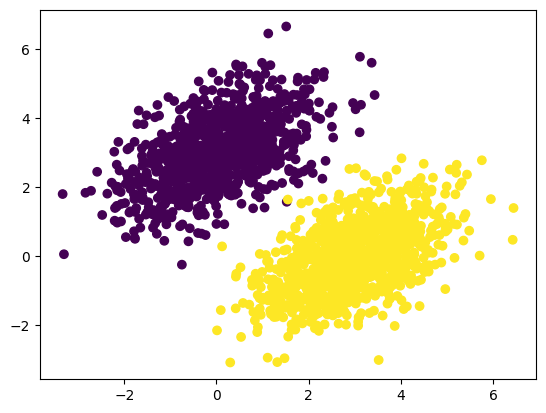

In [17]:
import numpy as np

num_samples_per_class = 1_000

# Generates the first class of points: 1_000 random 2D points with specified "mean" and "covariance" matrix.
# Intuitively, the "covariance matrix" describes the shape of the point cloud, and the "mean" describes its
# position in the plan.cov=[[1, 0.5], [0.5, 1]] corrresponds to "an oval-like point cloud oriented from bottom
# left to top right."
negative_samples = np.random.multivariate_normal(
    mean=[0, 3], cov=[[1, 0.5], [0.5, 1]], size=num_samples_per_class
)

# Generates the other class of points with a different mean and the same covariance matrix (point cloud with a
# different poistion and the same shape)
positive_samples = np.random.multivariate_normal(
    mean=[3, 0], cov=[[1, 0.5], [0.5, 1]], size=num_samples_per_class
)

inputs = np.vstack((negative_samples, positive_samples)).astype(np.float32)
inputs.shape

targets = np.vstack(
    (
        np.zeros((num_samples_per_class, 1), dtype="float32"),
        np.ones((num_samples_per_class, 1), dtype="float32"),
    )
)

import matplotlib.pyplot as plt

plt.scatter(inputs[:, 0], inputs[:, 1], c=targets[:, 0])
plt.show()

In [ ]:
def model(inputs, W, b):
    return jnp.matmul(inputs, W) + b


def mean_squared_error(targets, predictions):
    per_sample_losses = jnp.square(targets - predictions)
    return jnp.mean(per_sample_losses)

To compute gradients, we need to package loss computation in a single `compute_loss()`
function. It returns the total loss as a scalar, and it takes `state` as its first argument—a
tuple of all the tensors we need gradients for:

In [25]:
def compute_loss(state, inputs, targets):
    W, b = state
    predictions = model(inputs, W, b)
    loss = mean_squared_error(targets, predictions)
    return loss

Calling `jax.value_and_grad()` on this function gives us a new function, with the same
argument as` compute_loss`, which returns both the loss and the gradients of the loss
with regard to the elements of state:

In [26]:
grad_fn = jax.value_and_grad(compute_loss)

Next, we can set up our training step function. It looks straightforward. Be mindful
that, unlike its TensorFlow and PyTorch equivalents, it needs to be stateless, and so it
must return the updated values of the W and b tensors:

In [ ]:
learning_rate = 0.1


# We use the jax.jit decorator to take advantage of XLA compilation
@jax.jit
def training_stpes(inputs, targets, W, b):
    # computes the forward pass and backward pass in one go
    loss, grads = grad_fn((W, b), inputs, targets)

    # updates W and b
    grad_wrt_W, grad_wrt_b = grads
    W = W - grad_wrt_W * learning_rate
    b = b - grad_wrt_b * learning_rate

    # make sure to return the new values of W and b in addition to the loss
    return loss, W, b


Because we won’t change the `learning_rate` during our example, we can consider it
part of the function itself and not our model’s state. If we wanted to modify our learning
rate during training, we’d need to pass it through as well.
Finally, we’re ready to run the full training loop. We initialize W and b, and we repeatedly
update them via stateless calls to `training_step()`:

In [28]:
input_dim = 2
output_dim = 1

W = jax.numpy.array(np.random.uniform(size=(input_dim, output_dim)))
b = jax.numpy.array(np.zeros(shape=(output_dim,)))
state = (W, b)
for step in range(40):
    loss, W, b = training_stpes(inputs, targets, W, b)
    print(f"Loss at step {step}: {loss:.4f}")


Loss at step 0: 0.7095
Loss at step 1: 0.1814
Loss at step 2: 0.1124
Loss at step 3: 0.0978
Loss at step 4: 0.0904
Loss at step 5: 0.0844
Loss at step 6: 0.0791
Loss at step 7: 0.0742
Loss at step 8: 0.0698
Loss at step 9: 0.0657
Loss at step 10: 0.0621
Loss at step 11: 0.0587
Loss at step 12: 0.0557
Loss at step 13: 0.0529
Loss at step 14: 0.0504
Loss at step 15: 0.0481
Loss at step 16: 0.0460
Loss at step 17: 0.0441
Loss at step 18: 0.0423
Loss at step 19: 0.0407
Loss at step 20: 0.0393
Loss at step 21: 0.0380
Loss at step 22: 0.0368
Loss at step 23: 0.0357
Loss at step 24: 0.0347
Loss at step 25: 0.0338
Loss at step 26: 0.0330
Loss at step 27: 0.0322
Loss at step 28: 0.0315
Loss at step 29: 0.0309
Loss at step 30: 0.0304
Loss at step 31: 0.0298
Loss at step 32: 0.0294
Loss at step 33: 0.0289
Loss at step 34: 0.0285
Loss at step 35: 0.0282
Loss at step 36: 0.0279
Loss at step 37: 0.0276
Loss at step 38: 0.0273
Loss at step 39: 0.0271


#### Display the results

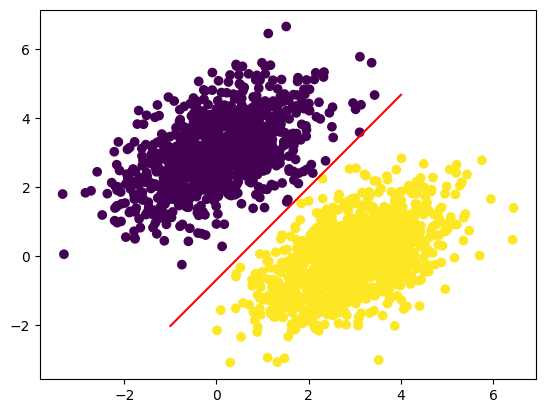

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Predictions with final training weights
predictions = model(inputs, W, b)

# Plot: points  + decision line
x = np.linspace(-1, 4, 100)
y = -np.array(W[0]) / np.array(W[1]) * x + (0.5 - np.array(b)) / np.array(W[1])
plt.plot(x, y, "-r")
plt.scatter(inputs[:, 0], inputs[:, 1], c=np.array(predictions[:, 0]) > 0.5)
plt.show()


That’s it! You’re now able to write a custom training loop in JAX.